# Imports

In [15]:
import subprocess
import os
import re
from datetime import datetime
from pathlib import Path
import json
from itertools import islice
import pandas as pd
import networkx as nx
import random
from src.vanilla_qaoa_result import run_vanilla_qaoa

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [16]:
from src.adapt_utils import (
    run_adapt_jl_parallel,
    show_adapt_logs,
    get_combined_res_df
)

# Config

In [17]:
adapt_gpt_dir = Path(
    "/home/mrzaizai2k/code_bao/ADAPT_GPT"
)
adapt_output_dir = "./ADAPT.jl_results/test/time"
n_graphs = 5
n_runs = 1
# input_graph_filename = "ADAPT.jl_results/graphs.json"

In [18]:
def add_weights_to_nx_graph(G, weighted=True, use_negative=False):
    elist = []
    for u, v in G.edges():
        if weighted:
            w = random.uniform(0.1, 1.0)
            if use_negative and random.random() < 0.5:
                w *= -1
        else:
            w = -1 if (use_negative and random.random() < 0.5) else 1

        elist.append([int(u)+1, int(v)+1, float(round(w, 2))])
        # +1 to match Julia 1-indexing
    return elist

def generate_graphs(
    n_graphs=10,
    n_nodes=10,
    density=None,          # if None → random
    weighted=True,
    use_negative=False
):
    graphs_dict = {}

    for i in range(n_graphs):
        if density is None:
            p = random.uniform(0.6, 0.9)   # random density
        else:
            p = density

        G = nx.erdos_renyi_graph(n=n_nodes, p=p)

        # avoid empty graph
        while G.number_of_edges() == 0:
            G = nx.erdos_renyi_graph(n=n_nodes, p=p)

        elist = add_weights_to_nx_graph(G, weighted, use_negative)

        graph_name = f"Graph_{i}_n{n_nodes}"

        graphs_dict[graph_name] = {
            "elist": elist,
            "n_nodes": n_nodes
        }

    return graphs_dict

def load_graphs(filename):
    with open(filename, "r") as f:
        return json.load(f)


def save_graphs_to_json(graphs_dict, filename):
    with open(filename, "w") as f:
        json.dump(graphs_dict, f, indent=2)

# Generate graphs

In [19]:
path_list = []
for i in [12,13,14]:
# for i in [4, 6, 8, 9, 10, 11]:
    graphs = generate_graphs(
        n_graphs=n_graphs,
        n_nodes=i,
        density=None,          # or e.g. 0.7
        weighted=True,
        use_negative=False
    )
    path = f"{adapt_output_dir}/graphs_n{i}.json"

    save_graphs_to_json(graphs, path)
    path_list.append(path)

# Load back
cur_input_graphs_dict = load_graphs(path)

# ADAPT QAOA result

In [20]:
adapt_folder_list = []
for path in path_list:
    filename = os.path.basename(path)
    match = re.search(r"graphs_n(\d+)", filename)

    if not match:
        raise ValueError(f"Cannot extract node number from {filename}")

    i = int(match.group(1))  # convert to int

    new_name = f"{adapt_output_dir}/graphs_n{i}/"
    adapt_folder_list.append(new_name)

    logs_list, cur_proc = run_adapt_jl_parallel(
        script_dir=adapt_gpt_dir,
        output_dir=new_name,
        input_graphs=path,
        n_workers=1,
        graphs_number=n_graphs,
        n_nodes=i,
        trials_per_graph=n_runs,
        max_params=50,
        gamma_0="gamma0_grid.json",
        pool_name="qaoa_double_pool",
        use_floor_stopper=True,
        temp_folder=f"{adapt_output_dir}/temp_data_n{i}",
    )

Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR
Splitting input graphs into 1 parts
Starting worker 0 on node: DESKTOP-H2CRQMR


In [29]:
show_adapt_logs(logs_list, n_lines=20)

Log: worker_DESKTOP-H2CRQMR_0
  trials-per-graph  =>  1
  run-qaoa  =>  true
  graphs-input-json  =>  ADAPT.jl_results/test/time/temp_data_n14/2026-05-06_11-47/chunk_0.json
  weighted  =>  true
  degen  =>  true
  use-floor-stopper  =>  true
  n-nodes  =>  14
  run-diag-qaoa  =>  true
  scaling-coef  =>  1.0
  save-state-vect  =>  false
Loading graphs from: ADAPT.jl_results/test/time/temp_data_n14/2026-05-06_11-47/chunk_0.json

Graphs on: unknown; pid: 34909: 0.0%┣                ┫ 0/5 [00:01<00:-7, -1s/it]
Any[]Pool size: 379

Graph name: Graph_3_n14;
Number of edges: 73;
Number of nodes: 14;
Generator: input_file.


--------------------------------------------------


# QAOA result

In [31]:
adapt_folder_list = ['./ADAPT.jl_results/test/time/graphs_n12/',
 './ADAPT.jl_results/test/time/graphs_n13/']

In [32]:
for path in adapt_folder_list:
    qaoa_df = run_vanilla_qaoa(
        data_path=path,
        depth=None,
        n_samples=None,
        n_runs=1
    )


=== RUN 1/1 ===
Running graph_1...
2026-05-06 15:28:07 [info     ] Calculating energy landscape for depth p=1... file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:15 [info     ] Executing sample_cost_landscape file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:15 [info     ] circuits: 400                  file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:15 [info     ] Done execute                   file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:28 [info     ] Done measurement               file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:28 [info     ] Calculating Energy landscape done file=qaoa.qaoa func=sample_cost_landscape
2026-05-06 15:28:29 [info     ] cost(depth 1 = -15.662421875000007 file=qaoa.qaoa func=optimize
2026-05-06 15:28:33 [info     ] cost(depth 2 = -16.033212890625016 file=qaoa.qaoa func=optimize
2026-05-06 15:28:38 [info     ] cost(depth 3 = -15.787099609375 file=qaoa.qaoa func=optimize
2026-05-06 15:28:48 [info     

In [33]:
qaoa_df.head()

,graph_name,n_nodes,edgelist_list_len,n_layers,expected_energy,variance,γ_coeff,β_coeff,approx_ratio,energy_mqlib,edgelist_list,took_time,method,optimizer,run_id
0,graph_1,13,55,13,-18.558154,0.620403,"[0.36683600212761963, 0.40314051792172906, 0.4418774125929915, 0.4652489148519897, 0.495013952982066, 0.5314827396586006, 0.5541885548766878, 0.5711159837603988, 0.5996052925626313, 0.6189172585087519, 0.6419993086729765, 0.6406808904134609, 0.6589543804789247]","[5.106010796272037, 5.053975078477333, 5.048291778946207, 4.9859624064322725, 4.97808693129516, 4.970265850912954, 4.9234151921969875, 4.928791661059887, 4.889190217916803, 4.859697981680814, 4.834360968491757, 4.8295079317931915, 4.80582791243273]",0.964561,-19.24,"[[1, 2, 0.8], [1, 3, 0.38], [1, 5, 0.74], [1, 6, 0.94], [1, 7, 0.9], [1, 8, 0.94], [1, 9, 0.13], [1, 10, 0.64], [1, 11, 0.49], [1, 13, 0.39], [2, 3, 0.19], [2, 4, 0.82], [2, 6, 0.36], [2, 8, 0.17], [2, 9, 0.36], [2, 10, 0.85], [2, 11, 0.34], [2, 13, 0.67], [3, 5, 0.35], [3, 8, 0.14], [3, 9, 0.89], [3, 10, 0.87], [3, 11, 0.99], [3, 12, 0.28], [3, 13, 0.85], [4, 5, 0.72], [4, 6, 0.2], [4, 7, 0.66], [4, 8, 0.92], [4, 9, 0.33], [4, 11, 0.33], [4, 12, 0.26], [4, 13, 0.72], [5, 6, 0.74], [5, 8, 0.85], [5, 9, 0.28], [5, 11, 0.6], [5, 13, 0.54], [6, 8, 0.89], [6, 9, 0.17], [6, 11, 0.19], [6, 12, 0.49], [7, 9, 0.15], [7, 10, 0.58], [7, 11, 0.16], [7, 13, 0.43], [8, 11, 0.1], [8, 12, 0.91], [8, 13, 0.15], [9, 10, 0.63], [9, 11, 0.45], [10, 12, 0.3], [10, 13, 0.49], [11, 13, 0.69], [12, 13, 0.33]]",381.812,vanilla_qaoa,BFGS,0
1,graph_2,13,54,13,-19.549580,1.840737,"[0.4550528349801535, 0.5095723813309395, 0.5377685382426455, 0.5785511834020494, 0.6131577554097158, 0.6541455281833313, 0.6997250399957988, 0.7398459800099615, 0.7752282141631391, 0.8076403968827979, 0.830863144102203, 0.8641512623933358, 0.9063147405795469]","[1.904390876094503, 1.8868693203887794, 1.8709137725326652, 1.8555913958834422, 1.8411816613194778, 1.826036991723141, 1.8079616534258196, 1.7899369544810297, 1.7752152256113594, 1.7582249738356233, 1.7276144037805505, 1.6809514220172852, 1.6245518891761253]",0.956437,-20.44,"[[1, 2, 0.54], [1, 3, 0.82], [1, 4, 0.82], [1, 6, 0.42], [1, 7, 0.34], [1, 8, 0.64], [1, 9, 0.34], [1, 11, 0.71], [1, 12, 0.92], [1, 13, 0.55], [2, 3, 0.85], [2, 4, 0.66], [2, 7, 0.74], [2, 8, 0.65], [2, 9, 0.45], [2, 10, 0.22], [2, 11, 0.16], [2, 12, 0.69], [3, 4, 0.2], [3, 6, 0.32], [3, 7, 0.83], [3, 9, 0.62], [3, 10, 0.48], [3, 11, 0.42], [3, 12, 0.25], [4, 5, 0.64], [4, 6, 0.29], [4, 7, 0.79], [4, 8, 0.38], [4, 9, 0.37], [4, 11, 0.42], [4, 12, 0.86], [5, 7, 0.13], [5, 8, 0.96], [5, 9, 0.16], [5, 10, 0.76], [5, 11, 0.82], [5, 13, 0.36], [6, 9, 0.32], [6, 11, 0.33], [6, 12, 0.29], [7, 8, 0.71], [7, 9, 0.63], [7, 11, 0.58], [7, 12, 0.38], [8, 9, 0.97], [8, 10, 0.73], [9, 10, 0.95], [9, 13, 0.2], [10, 11, 0.99], [10, 13, 0.45], [11, 12, 0.56], [11, 13, 0.45], [12, 13, 0.78]]",365.817,vanilla_qaoa,BFGS,0
2,graph_3,13,57,13,-18.044590,2.730342,"[0.4552721391607451, 0.48801036191078057, 0.5024460719601453, 0.48734931861617065, 0.4581757648023654, 0.45259375176208794, 0.46296207270998146, 0.4600362528275605, 0.4471454970572466, 0.461218938468836, 0.5146131518209821, 0.5565852938928803, 0.5327898372652514]","[3.396437461547881, 3.3793160321584472, 3.3659605664170416, 3.3432220823441767, 3.309650643353436, 3.277373164625372, 3.26568561614894, 3.2802472391970343, 3.2996163409431807, 3.2921395386315258, 3.2622302152371923, 3.278497208994881, 3.368548387726906]",0.898635,-20.08,"[[2, 3, 0.24], [2, 4, 0.9], [2, 5, 0.73], [2, 9, 0.48], [2, 10, 0.48], [2, 11, 0.46], [2, 12, 0.12], [3, 4, 0.35], [3, 5, 0.6], [3, 6, 0.19], [3, 7, 0.77], [3, 10, 0.89], [3, 11, 0.77], [3, 13, 0.48], [1, 4, 0.11], [1, 5, 0.79], [1, 6, 0.79], [1, 7, 0.27], [1, 8, 0.43], [1, 9, 0.28], [1, 10, 0.35], [1, 13, 0.45], [4, 5, 0.37], [4, 7, 0.87], [4, 9, 0.85], [4, 10, 0.13], [4, 13, 0.44], [5, 6, 0.18], [5, 7, 0.77], [5, 8, 0.18], [5, 9, 0.62], [5, 10, 0.29], [5, 11, 0.

# LLMs

In [42]:
# ------------------------
# IMPORTS
# ------------------------
import time
import numpy as np
import torch
import glob
from src.adapt_utils import compute_metrics_per_graph
from src.model_interface import QAOA_GPT
from src.utils import (
    attach_resolved_names,
    load_and_aggregate_adapt,
    build_results_df,
    build_final_df,
    build_summary_df,
)
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [43]:
# ── Model Configs ────────────────────────────────────────────
# Each entry: ckpt, data_dir, and optionally name.
# Auto-extraction from ckpt filename: arch (element[0]) + method (element[3])
# e.g. "llama_ckpt_5000_feather_ar_0_89184__er_0_0.pt" → "LLaMA-Feather"
# Provide `name` explicitly to override auto-extraction.

MODEL_CONFIGS = [
    dict(
        ckpt="nanoGPT/out-11_nodes_feather/llama_ckpt_5000_feather_ar_0_89184__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_gnn/llama_ckpt_4500_gnn_ar_0_91473__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_gnn",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_netlsd/llama_ckpt_5000_netlsd_ar_0_9264__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_netlsd",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_feather/gpt_ckpt_3000_feather_ar_0_96249__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_feather",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_gnn/gpt_ckpt_2500_gnn_ar_0_95371__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_gnn",
    ),
    dict(
        ckpt="nanoGPT/out-11_nodes_netlsd/gpt_ckpt_4000_netlsd_ar_0_96605__er_0_0.pt",
        data_dir="nanoGPT/data/11_nodes_netlsd",
    ),
]

In [44]:
# ── Config ──────────────────────────────────────────────────
SEED            = 1337
BASE_DIR        = adapt_output_dir           # reuse from above
MAX_TOKENS      = 200
LLM_TEMPERATURE = 0.1
LLM_TOP_K       = 200
N_SAMPLES       = 5
# ───────────────────────

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_CONFIGS = attach_resolved_names(MODEL_CONFIGS)
print(f"MODEL_CONFIGS: {MODEL_CONFIGS}")

Resolved model names:
  LLaMA-Feather  (arch=LLaMA, method=Feather)
  LLaMA-GNN  (arch=LLaMA, method=GNN)
  LLaMA-NetLSD  (arch=LLaMA, method=NetLSD)
  NanoGPT-Feather  (arch=NanoGPT, method=Feather)
  NanoGPT-GNN  (arch=NanoGPT, method=GNN)
  NanoGPT-NetLSD  (arch=NanoGPT, method=NetLSD)
MODEL_CONFIGS: [{'ckpt': 'nanoGPT/out-11_nodes_feather/llama_ckpt_5000_feather_ar_0_89184__er_0_0.pt', 'data_dir': 'nanoGPT/data/11_nodes_feather', 'resolved_name': 'LLaMA-Feather', 'arch': 'LLaMA', 'method': 'Feather'}, {'ckpt': 'nanoGPT/out-11_nodes_gnn/llama_ckpt_4500_gnn_ar_0_91473__er_0_0.pt', 'data_dir': 'nanoGPT/data/11_nodes_gnn', 'resolved_name': 'LLaMA-GNN', 'arch': 'LLaMA', 'method': 'GNN'}, {'ckpt': 'nanoGPT/out-11_nodes_netlsd/llama_ckpt_5000_netlsd_ar_0_9264__er_0_0.pt', 'data_dir': 'nanoGPT/data/11_nodes_netlsd', 'resolved_name': 'LLaMA-NetLSD', 'arch': 'LLaMA', 'method': 'NetLSD'}, {'ckpt': 'nanoGPT/out-11_nodes_feather/gpt_ckpt_3000_feather_ar_0_96249__er_0_0.pt', 'data_dir': 'nanoGPT

# Helper functions

In [48]:
def get_graph_folders(base_dir: str) -> list[str]:
    """Return all graphs_nXX sub-folders (directories only), sorted by node count."""
    pattern = os.path.join(base_dir, "graphs_n*")
    folders = sorted([
        p for p in glob.glob(pattern)
        if os.path.isdir(p)
    ])
    return folders


def qaoa_time_mean(folder: str) -> tuple[float, int]:
    qaoa_dir = os.path.join(folder, "qaoa_result")
    matches = glob.glob(os.path.join(qaoa_dir, "qaoa_*.csv"))

    if not matches:
        raise FileNotFoundError(f"No qaoa_*.csv found in {qaoa_dir}")

    csv_path = matches[0]
    print(f"        Reading: {csv_path}")
    df = pd.read_csv(csv_path)

    n_runs = df["run_id"].nunique()
    per_graph = df.groupby("graph_name")["took_time"].mean()
    grand_mean = per_graph.mean()

    return grand_mean, n_runs


def adapt_time_mean(folder: str) -> tuple[float, int]:
    _, adapt_agg, _, _ = load_and_aggregate_adapt(folder)

    mean_time = adapt_agg["adapt_time_mean"].mean()
    n_runs = int(adapt_agg["adapt_n_runs"].mode()[0])

    return mean_time, n_runs


def llm_time_mean(
    folder: str,
    graphs_unique,
    n_runs: int,
    n_nodes: int,
    model_configs: list,
) -> dict:
    """
    Run each model in model_configs on graphs_unique and return a dict
    mapping resolved_name → mean time per run.
    """
    times = {}
    for cfg in model_configs:
        model_name = cfg["resolved_name"]
        model = QAOA_GPT(model_ckpt=cfg["ckpt"], data_dir=cfg["data_dir"])
        model.n_nodes = n_nodes

        t0 = time.perf_counter()
        df_model = model.generate_circ_from_nx(
            graphs_unique,
            num_samples=n_runs,
            max_new_tokens=MAX_TOKENS,
            temperature=LLM_TEMPERATURE,
            top_k=LLM_TOP_K,
            allow_larger_graphs=True,
        )
        total_wall = time.perf_counter() - t0

        if "took_time" in df_model.columns:
            per_run = df_model["took_time"].sum() / (len(df_model) * n_runs)
        else:
            per_run = total_wall / (len(graphs_unique) * n_runs)

        times[model_name] = per_run
    return times


def llm_ar_mean(
    graphs_unique,
    n_nodes: int,
    model_configs: list,
) -> dict:
    """
    Run each model in model_configs, evaluate circuits, and return a dict
    mapping resolved_name → mean AR across graphs.
    """
    ar_results = {}
    for cfg in model_configs:
        model_name = cfg["resolved_name"]
        model = QAOA_GPT(model_ckpt=cfg["ckpt"], data_dir=cfg["data_dir"])
        model.n_nodes = n_nodes

        df_model = model.generate_circ_from_nx(
            graphs_unique,
            num_samples=N_SAMPLES,
            max_new_tokens=MAX_TOKENS,
            temperature=LLM_TEMPERATURE,
            top_k=LLM_TOP_K,
            allow_larger_graphs=True,
        )
        df_eval = model.eval_circ_df_jl(df_model)
        ar, layers, error_rate = compute_metrics_per_graph(df_eval)

        # ar is per-graph; take the mean across graphs
        ar_results[model_name] = float(np.mean(ar))
    return ar_results

# Build timing + AR summary

In [49]:
def build_timing_ar_summary(model_configs: list) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns
    -------
    timing_df : columns [folder, n_nodes, n_runs, qaoa_time_mean_s,
                          adapt_time_mean_s, <model>_time_mean_s, ...]
    ar_df     : columns [folder, n_nodes, qaoa_ar_mean, adapt_ar_mean,
                          <model>_ar_mean, ...]
    """
    folders = get_graph_folders(BASE_DIR)
    if not folders:
        raise FileNotFoundError(f"No graphs_nXX folders found under {BASE_DIR}")

    timing_records = []
    ar_records = []

    for folder in folders:
        folder_name = os.path.basename(folder)
        n_nodes = int(folder_name.replace("graphs_n", ""))

        print(f"\n{'='*55}")
        print(f"Processing {folder_name}  (n_nodes={n_nodes})")
        print(f"{'='*55}")

        # ── 1. QAOA timing ──────────────────────────────────
        print("  [1/4] Reading QAOA times …")
        try:
            qaoa_mean_time, n_runs_qaoa = qaoa_time_mean(folder)
            print(f"        QAOA mean time/run = {qaoa_mean_time:.4f}s  (n_runs={n_runs_qaoa})")
        except FileNotFoundError:
            print("        qaoa_result not found – skipping QAOA.")
            qaoa_mean_time, n_runs_qaoa = np.nan, np.nan

        # ── 2. ADAPT timing ─────────────────────────────────
        print("  [2/4] Loading ADAPT aggregation …")
        try:
            adapt_mean_time, n_runs_adapt = adapt_time_mean(folder)
            print(f"        ADAPT mean time/run = {adapt_mean_time:.4f}s  (n_runs={n_runs_adapt})")
        except Exception as e:
            print(f"        ADAPT load failed: {e}")
            adapt_mean_time, n_runs_adapt = np.nan, np.nan

        n_runs = int(n_runs_adapt if not np.isnan(n_runs_adapt) else n_runs_qaoa)

        # Load graphs + adapt aggregation for AR
        _, adapt_agg, graphs_unique, meta_df = load_and_aggregate_adapt(folder)

        # ── 3. LLM timing ───────────────────────────────────
        print(f"  [3/4] Running LLM inference for timing  (n_runs={n_runs}) …")
        try:
            llm_times = llm_time_mean(folder, graphs_unique, n_runs, n_nodes, model_configs)
            for name, t in llm_times.items():
                print(f"        {name} mean time/run = {t:.4f}s")
        except Exception as e:
            print(f"        LLM timing failed: {e}")
            llm_times = {cfg["resolved_name"]: np.nan for cfg in model_configs}

        # ── 4. AR comparison ────────────────────────────────
        print(f"  [4/4] Computing AR for all methods …")

        # QAOA AR
        try:
            qaoa_csv = glob.glob(os.path.join(folder, "qaoa_result", "qaoa_*.csv"))[0]
            qaoa_res = pd.read_csv(qaoa_csv)
            qaoa_ar_mean = qaoa_res.groupby("graph_name")["approx_ratio"].mean().mean()
            print(f"        QAOA mean AR = {qaoa_ar_mean:.4f}")
        except Exception as e:
            print(f"        QAOA AR failed: {e}")
            qaoa_ar_mean = np.nan

        # ADAPT AR
        try:
            adapt_ar_mean = adapt_agg["adapt_ar_mean"].mean()
            print(f"        ADAPT mean AR = {adapt_ar_mean:.4f}")
        except Exception as e:
            print(f"        ADAPT AR failed: {e}")
            adapt_ar_mean = np.nan

        # LLM AR
        try:
            llm_ars = llm_ar_mean(graphs_unique, n_nodes, model_configs)
            for name, ar in llm_ars.items():
                print(f"        {name} mean AR = {ar:.4f}")
        except Exception as e:
            print(f"        LLM AR failed: {e}")
            llm_ars = {cfg["resolved_name"]: np.nan for cfg in model_configs}

        # Build records
        timing_row = {
            "folder":            folder_name,
            "n_nodes":           n_nodes,
            "n_runs":            n_runs,
            "qaoa_time_mean_s":  round(qaoa_mean_time,  6),
            "adapt_time_mean_s": round(adapt_mean_time, 6),
        }
        timing_row.update({f"{k}_time_mean_s": round(v, 6) for k, v in llm_times.items()})
        timing_records.append(timing_row)

        ar_row = {
            "folder":       folder_name,
            "n_nodes":      n_nodes,
            "qaoa_ar_mean": round(qaoa_ar_mean,  6),
            "adapt_ar_mean": round(adapt_ar_mean, 6),
        }
        ar_row.update({f"{k}_ar_mean": round(v, 6) for k, v in llm_ars.items()})
        ar_records.append(ar_row)

    timing_df = (
        pd.DataFrame(timing_records)
        .sort_values("n_nodes")
        .reset_index(drop=True)
    )
    ar_df = (
        pd.DataFrame(ar_records)
        .sort_values("n_nodes")
        .reset_index(drop=True)
    )
    return timing_df, ar_df

In [50]:
timing_summary, ar_summary = build_timing_ar_summary(MODEL_CONFIGS)

print("\n=== Timing Summary ===")
print(timing_summary.to_string(index=False))

print("\n=== AR Summary ===")
print(ar_summary.to_string(index=False))


Processing graphs_n10  (n_nodes=10)
  [1/4] Reading QAOA times …
        Reading: ./ADAPT.jl_results/test/time/graphs_n10/qaoa_result/qaoa_05_17_17.csv
        QAOA mean time/run = 84.8916s  (n_runs=1)
  [2/4] Loading ADAPT aggregation …
Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/time/graphs_n10


Opening ADAPT results (graphs_n10): 100%|██████████| 1/1 [00:00<00:00, 260.35it/s]


df_list len: 1


Opening graphs (graphs_n10): 100%|██████████| 1/1 [00:00<00:00, 536.08it/s]


df_list len: 1
Graphs count:
g_method
input_file    5
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 6
Unique graphs         : 1
Runs per graph (mean) : 6.00

Aggregated ADAPT shape : (1, 9)
Graphs fed to model    : 1
        ADAPT mean time/run = 9.1345s  (n_runs=6)
Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/time/graphs_n10


...


===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_39_59_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_39_59_df_jl.json 9 qaoa_double_pool


Julia return code: 0

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: netlsd
Number of nodes: 11
Initiating nanoGPT model with padding support
number of parameters: 11.71M


Preparing graphs...: 100%|██████████| 1/1 [00:00<00:00, 96.39it/s]


Performing netlsd embedding


NetLSD: 100%|██████████| 1/1 [00:00<00:00, 320.89it/s]
Inference. Current batch: n_edges: 24, n_graphs: 1: 100%|██████████| 1/1 [00:00<00:00,  1.47it/s]



===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_40_08_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_40_08_df_jl.json 9 qaoa_double_pool


Julia return code: 0
        LLaMA-Feather mean AR = 0.6575
        LLaMA-GNN mean AR = 0.6575
        LLaMA-NetLSD mean AR = 0.6652
        NanoGPT-Feather mean AR = 0.6730
        NanoGPT-GNN mean AR = 0.6546
        NanoGPT-NetLSD mean AR = 0.6573

=== Timing Summary ===
    folder  n_nodes  n_runs  qaoa_time_mean_s  adapt_time_mean_s  LLaMA-Feather_time_mean_s  LLaMA-GNN_time_mean_s  LLaMA-NetLSD_time_mean_s  NanoGPT-Feather_time_mean_s  NanoGPT-GNN_time_mean_s  NanoGPT-NetLSD_time_mean_s
 graphs_n4        4       5            3.3616           1.564911             

In [51]:
timing_summary.to_csv(f"{BASE_DIR}/timing_summary.csv", index=False)
ar_summary.to_csv(f"{BASE_DIR}/ar_summary.csv", index=False)

# Plots

In [52]:
def plot_timing_comparison(summary_df: pd.DataFrame, save_path: str = None, log_scale: bool = False):
    fig, ax = plt.subplots(figsize=(8, 8))

    # Fixed methods
    fixed_methods = {
        "QAOA":  ("qaoa_time_mean_s",  "o-",  "#E74C3C"),
        "ADAPT": ("adapt_time_mean_s", "s--", "#3498DB"),
    }

    # LLM model columns (everything else ending in _time_mean_s)
    llm_cols = [c for c in summary_df.columns
                if c.endswith("_time_mean_s")
                and c not in ("qaoa_time_mean_s", "adapt_time_mean_s")]

    colors_llm = plt.cm.tab10.colors

    for label, (col, style, color) in fixed_methods.items():
        ax.plot(
            summary_df["n_nodes"], summary_df[col],
            style, color=color, linewidth=2, markersize=8, label=label,
        )

    for idx, col in enumerate(llm_cols):
        label = col.replace("_time_mean_s", "")
        ax.plot(
            summary_df["n_nodes"], summary_df[col],
            "^:", color=colors_llm[idx % len(colors_llm)],
            linewidth=2, markersize=8, label=label,
        )

    ax.set_title("Mean Inference Time per Method vs Graph Size", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Number of Nodes", fontsize=13)
    ax.set_xticks(summary_df["n_nodes"])
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylabel("Mean Time per Run (s) — log scale", fontsize=13)
    else:
        ax.set_ylabel("Mean Time per Run (s)", fontsize=13)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved → {save_path}")
    plt.show()


def plot_ar_comparison(ar_df: pd.DataFrame, save_path: str = None):
    fig, ax = plt.subplots(figsize=(8, 8))

    fixed_methods = {
        "QAOA":  ("qaoa_ar_mean",  "o-",  "#E74C3C"),
        "ADAPT": ("adapt_ar_mean", "s--", "#3498DB"),
    }

    llm_cols = [c for c in ar_df.columns
                if c.endswith("_ar_mean")
                and c not in ("qaoa_ar_mean", "adapt_ar_mean")]

    colors_llm = plt.cm.tab10.colors

    for label, (col, style, color) in fixed_methods.items():
        ax.plot(
            ar_df["n_nodes"], ar_df[col],
            style, color=color, linewidth=2, markersize=8, label=label,
        )

    for idx, col in enumerate(llm_cols):
        label = col.replace("_ar_mean", "")
        ax.plot(
            ar_df["n_nodes"], ar_df[col],
            "^:", color=colors_llm[idx % len(colors_llm)],
            linewidth=2, markersize=8, label=label,
        )

    ax.set_title("Mean Approximation Ratio per Method vs Graph Size", fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel("Number of Nodes", fontsize=13)
    ax.set_ylabel("Mean AR", fontsize=13)
    ax.set_xticks(ar_df["n_nodes"])
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved → {save_path}")
    plt.show()

Saved → ./ADAPT.jl_results/test/time/timing_comparison.png


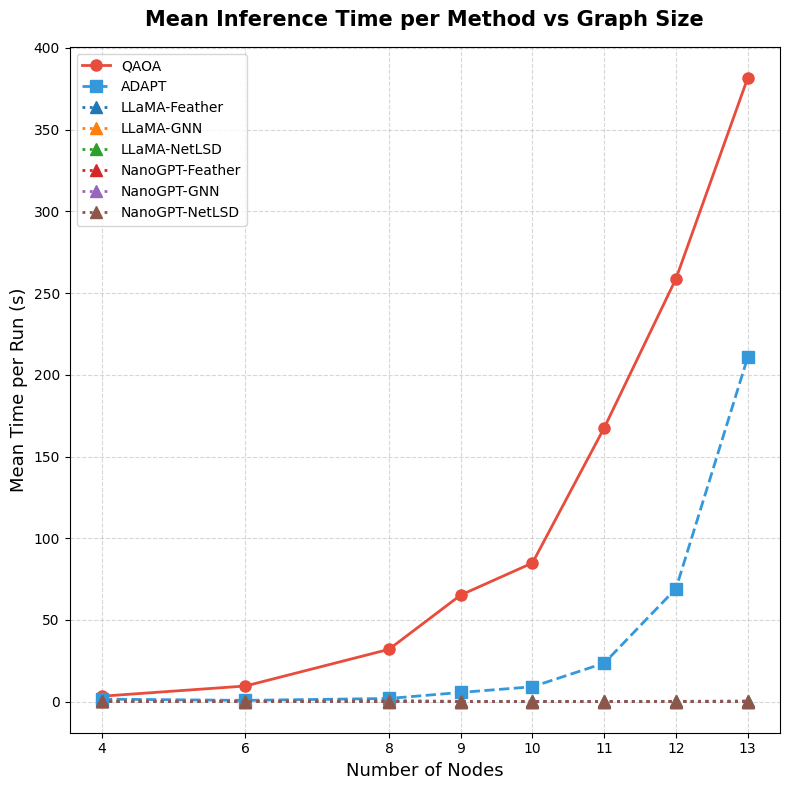

Saved → ./ADAPT.jl_results/test/time/timing_comparison_log.png


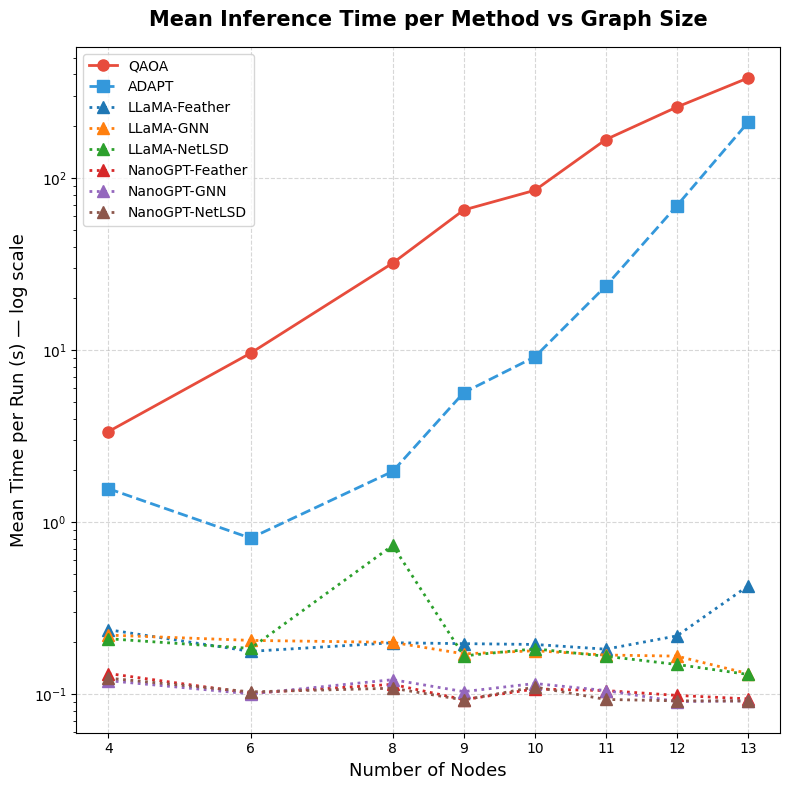

In [53]:
plot_timing_comparison(timing_summary, save_path=f"{BASE_DIR}/timing_comparison.png")
plot_timing_comparison(timing_summary, save_path=f"{BASE_DIR}/timing_comparison_log.png", log_scale=True)

Saved → ./ADAPT.jl_results/test/time/ar_comparison.png


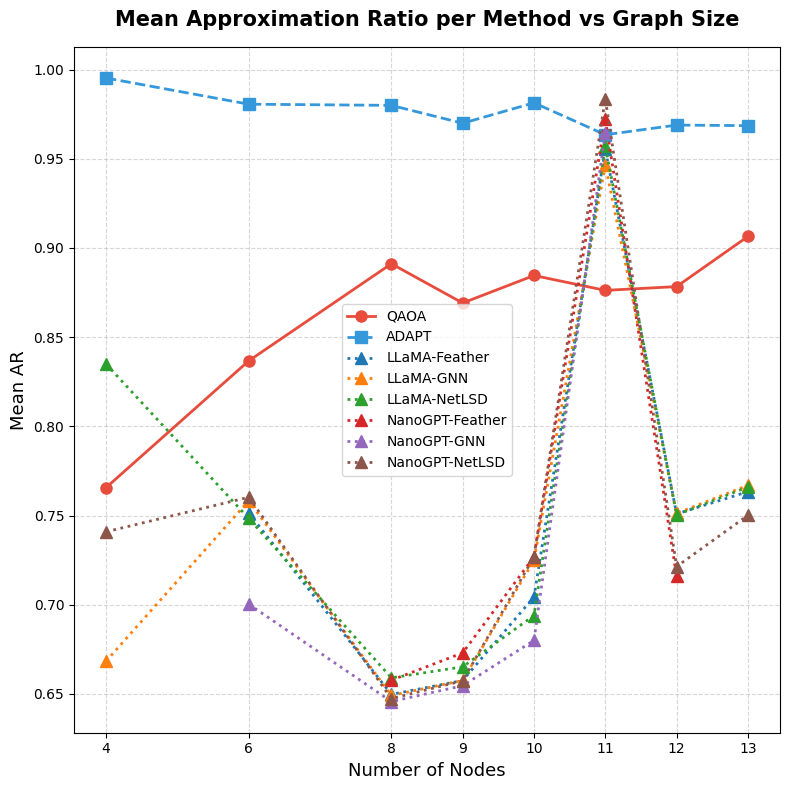

In [54]:
plot_ar_comparison(ar_summary, save_path=f"{BASE_DIR}/ar_comparison.png")

# Test

In [55]:
_, adapt_agg, graphs_unique, meta_df = load_and_aggregate_adapt("ADAPT.jl_results/test/time/graphs_n13")
model = QAOA_GPT(model_ckpt="nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt", 
                 data_dir="nanoGPT/data/10_nodes_feather")
model.n_nodes = 11

df_model = model.generate_circ_from_nx(
    graphs_unique,
    num_samples=N_SAMPLES,
    max_new_tokens=MAX_TOKENS,
    temperature=LLM_TEMPERATURE,
    top_k=LLM_TOP_K,
    allow_larger_graphs=True,  # allow generating circuits for larger graphs than seen in training
)
df_eval = model.eval_circ_df_jl(df_model)

Reading ADAPT.jl results from:
	 /home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl_results/test/time/graphs_n13


Opening ADAPT results (graphs_n13): 100%|██████████| 1/1 [00:00<00:00, 57.60it/s]


df_list len: 1


Opening graphs (graphs_n13): 100%|██████████| 1/1 [00:00<00:00, 502.19it/s]

df_list len: 1
Graphs count:
g_method
input_file    5
Name: count, dtype: int64
Aggregating results...
Total ADAPT rows      : 9
Unique graphs         : 1
Runs per graph (mean) : 9.00

Aggregated ADAPT shape : (1, 9)
Graphs fed to model    : 1

Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10


Initiating nanoGPT model with padding support
number of parameters: 11.68M


Preparing graphs...: 100%|██████████| 1/1 [00:00<00:00, 63.57it/s]


Performing feather embedding


100%|██████████| 1/1 [00:00<00:00, 597.56it/s]
Inference. Current batch: n_edges: 55, n_graphs: 1:   0%|          | 0/1 [00:00<?, ?it/s]/home/mrzaizai2k/code_bao/ADAPT_GPT/src/circuit_util.py:104: UserWarning: OOV token (1, 11) could not be remapped (no match after modulo); using token 0.
  encode = lambda s: [_remap_token(c) for c in s]
/home/mrzaizai2k/code_bao/ADAPT_GPT/src/circuit_util.py:104: UserWarning: OOV token (2, 11) could not be remapped (no match after modulo); using token 0.
  encode = lambda s: [_remap_token(c) for c in s]
/home/mrzaizai2k/code_bao/ADAPT_GPT/src/circuit_util.py:104: UserWarning: OOV token (2, 13) could not be remapped (no match after modulo); using token 0.
  encode = lambda s: [_remap_token(c) for c in s]
/home/mrzaizai2k/code_bao/ADAPT_GPT/src/circuit_util.py:104: UserWarning: OOV token (3, 11) could not be remapped (no match after modulo); using token 0.
  encode = lambda s: [_remap_token(c) for c in s]
/home/mrzaizai2k/code_bao/ADAPT_GPT/src/circuit_


===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_40_17_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-06__16_40_17_df_jl.json 11 qaoa_double_pool


Julia return code: 0


In [56]:
df_eval.head()


,graph_prefix,graph,n_edges,q_circuits,adapt_gpt_energies,energy_gurobi
0,graph_0,"[[1, 2], 0.8, [1, 3], 0.38, [1, 5], 0.74, [1, 6], 0.9400000000000001, [1, 7], 0.9, [1, 8], 0.9400000000000001, [1, 9], 0.13, [1, 10], 0.64, [1, 11], 0.49, [1, 13], 0.39, [2, 3], 0.19, [2, 4], 0.8200000000000001, [2, 6], 0.36, [2, 8], 0.17, [2, 9], 0.36, [2, 10], 0.85, [2, 11], 0.34, [2, 13], 0.67, [3, 5], 0.35000000000000003, [3, 8], 0.14, [3, 9], 0.89, [3, 10], 0.87, [3, 11], 0.99, [3, 12], 0.28, [3, 13], 0.85, [4, 5], 0.72, [4, 6], 0.2, [4, 7], 0.66, [4, 8], 0.92, [4, 9], 0.33, [4, 11], 0.33, [4, 12], 0.26, [4, 13], 0.72, [5, 6], 0.74, [5, 8], 0.85, [5, 9], 0.28, [5, 11], 0.6000000000000001, [5, 13], 0.54, [6, 8], 0.89, [6, 9], 0.17, [6, 11], 0.19, [6, 12], 0.49, [7, 9], 0.15, [7, 10], 0.58, [7, 11], 0.16, [7, 13], 0.43, [8, 11], 0.1, [8, 12], 0.91, [8, 13], 0.15, [9, 10], 0.63, ...]",55,"[[new_layer_p, 11, -0.45, 0.27, new_layer_p, 77, -0.04, 0.53, new_layer_p, 11, -0.36, 0.46, new_layer_p, 185, -0.04, 0.46, new_layer_p, 11, -0.30000000000000004, 0.46, new_layer_p, 25, -0.05, 0.6000000000000001, new_layer_p, 11, -0.28, 0.12, new_layer_p, 125, -0.05, 0.88, new_layer_p, 11, -0.26, -0.15, new_layer_p, 125, -0.05, 0.06, new_layer_p, 11, -0.25, 0.78, new_layer_p, 11, -0.23, 0.92, new_layer_p, 17, -0.13, 0.11, new_layer_p, 11, -0.17, 0.92, new_layer_p, 11, -0.13, 0.14], [new_layer_p, 11, -0.45, 0.26, new_layer_p, 73, -0.04, 0.55, new_layer_p, 11, -0.35000000000000003, 0.25, new_layer_p, 157, -0.05, 0.53, new_layer_p, 11, -0.32, 0.07, new_layer_p, 29, -0.05, 0.74, new_layer_p, 11, -0.29, -0.05, new_layer_p, 29, -0.05, 0.06, new_layer_p, 11, -0.25, 0.72, new_layer_p, 29, -0.05, -0.01, new_layer_p, 11, -0.23, 0.85, new_layer_p, 11, -0.23, 0.03, new_layer_p, 17, -0.05, 0.03, new_layer_p, 11, -0.18, 0.92, new_layer_p, 11, -0.15, 0.11], [new_layer_p, 11, -0.45, 0.26, new_layer_p, 77, -0.04, 0.55, new_layer_p, 11, -0.33, 0.53, new_layer_p, 25, -0.05, 0.44, new_layer_p, 11, -0.31, 0.06, new_layer_p, 157, -0.05, 0.8200000000000001, new_layer_p, 11, -0.29, -0.15, new_layer_p, 61, -0.05, 0.06, new_layer_p, 11, -0.25, 0.78, new_layer_p, 29, -0.05, 0.06, new_layer_p, 11, -0.23, 0.8300000000000001, new_layer_p, 11, -0.21, 0.03, new_layer_p, 129, -0.15, 1.0, new_layer_p, 11, -0.13, 0.13], [new_layer_p, 11, -0.45, 0.26, new_layer_p, 77, -0.06, 0.56, new_layer_p, 11, -0.35000000000000003, 0.25, new_layer_p, 25, -0.05, 0.46, new_layer_p, 11, -0.31, 0.44, new_layer_p, 157, -0.05, 0.76, new_layer_p, 11, -0.29, -0.05, new_layer_p, 17, -0.05, 0.01, new_layer_p, 11, -0.27, 0.78, new_layer_p, 11, -0.25, 0.06, new_layer_p, 125, -0.11, 0.08, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.18, 0.04, new_layer_p, 17, -0.14, 1.04, new_layer_p, 11, -0.11, 0.08], [new_layer_p, 11, -0.45, 0.25, new_layer_p, 77, -0.04, 0.55, new_layer_p, 11, -0.36, 0.27, new_layer_p, 25, -0.05, 0.46, new_layer_p, 11, -0.31, 0.44, new_layer_p, 77, -0.05, 0.76, new_layer_p, 11, -0.29, -0.12, new_layer_p, 29, -0.05, 0.06, new_layer_p, 11, -0.25, 0.77, new_layer_p, 11, -0.25, 0.75, new_layer_p, 29, -0.05, 0.01, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.17, 0.03, new_layer_p, 177, -0.23, 1.0, new_layer_p, 11, -0.11, 0.11]]","[-10.895014904293916, -10.932817180220585, -10.819841640572063, -10.92460655136659, -10.837978137760091]",-19.24


In [57]:
ar, layers, error_rate = compute_metrics_per_graph(df_eval)

In [58]:
ar, layers, error_rate

(0    0.565595
 Name: ar, dtype: object,
 0    14.8
 Name: q_circuits, dtype: float64,
 0    0.0
 Name: adapt_gpt_energies, dtype: float64)